# Weight of Evidence & Information Value — Home Credit Default Risk

A full practice workbook covering the WOE / IV skills you need to turn raw features into scorecard-ready inputs for a Probability of Default (PD) model, built on `application_train.csv`.

**How to use this notebook**

1. Work through sections in order — WOE from first principles first, then IV, then binning, then transformation, then the pitfalls, then a capstone.
2. Each section gives you brief context and the key syntax, then exercises. Write your code in the empty cells.
3. Every section also has **interpretation questions** — answer them in the markdown cells provided. In scorecard work the *reasoning* (why this binning, why this convention, why this feature survives) is the deliverable — the code is just how you get there.
4. There are **conceptual challenges** scattered throughout marked 🧠. Some have no code at all — they are there to catch the misconceptions that quietly wreck a scorecard. Answer them cold, then check yourself.
5. Bring your attempts to Claude for marking, or ask for hints when stuck. Try each exercise cold first.

**Ground rules**

- **Fix your convention once, in Section 1, and never flip it.** WOE has two sign conventions and mixing them is the single most common WOE bug. Write your choice at the top and obey it everywhere.
- **Learn every bin, every WOE, every IV on the training split only.** The validation rows never touch a WOE calculation until you *apply* a train-learned mapping to them. Leakage here inflates every downstream metric.
- **Every WOE table gets an IV, and every binning gets a monotonicity check.** Build the habit now.
- **State the minimum bin size you will accept before you look at the rates.** Deciding "5% or 200 rows, whichever is larger" *after* seeing a tempting cell rate is how you fool yourself.
- Before computing a WOE table, predict the *shape* — which bins should be safe, which risky. If the WOE trend surprises you, that is a finding. Write it down.

## 0 — Setup, data loading, and the good/bad frame

Run these cells to get started. The load cell follows your usual repo-relative pattern — adjust the path if your data lives elsewhere. This section also sets up the one framing decision everything else depends on: **who is the "bad"**.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", 130)
pd.set_option("display.width", 160)
print("pandas:", pd.__version__)
print("numpy :", np.__version__)

pandas: 3.0.3
numpy : 2.4.6


In [3]:
from pathlib import Path

def find_repo_root(marker=".git"):
    p = Path.cwd()
    for parent in [p, *p.parents]:
        if (parent / marker).exists():
            return parent
    return p

# REPO_ROOT = find_repo_root()
# DATA_PATH = REPO_ROOT / "Data" / "home-credit-default-risk" / "application_train.csv"

df = pd.read_csv('../../Datasets/Home Credit Default Risk/application_train.csv')
print(df.shape)

(307511, 122)


### Derived columns

Reuse the clean columns you built in 1.5 so the WOE work reads cleanly. `DAYS_*` columns are negative day counts; flip them once here.

In [4]:
# Derived columns (same conventions as your 1.5 workbook)
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365.25

df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] / 365.25
# The +365243 sentinel encodes "not employed" (pensioners etc.). Mask it to NaN.
df['YEARS_EMPLOYED_CLEAN'] = df['YEARS_EMPLOYED'].mask(df['DAYS_EMPLOYED'] == 365243, np.nan)

df['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT']  / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

df[['AGE_YEARS', 'YEARS_EMPLOYED_CLEAN', 'CREDIT_INCOME_RATIO']].describe()

C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\1976583697.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365.25
C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\1976583697.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['YEARS_EMPLOYED'] = -df['DAYS_EMPLOYED'] / 365.25
C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\1976583697.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performanc

,AGE_YEARS,YEARS_EMPLOYED_CLEAN,CREDIT_INCOME_RATIO
count,307511.000000,252137.000000,307511.000000
mean,43.906900,6.527500,3.957570
std,11.947950,6.402081,2.689728
min,20.503765,0.000000,0.004808
25%,33.984942,2.099932,2.018667
50%,43.121150,4.511978,3.265067
75%,53.886379,8.692676,5.159880
max,69.073238,49.040383,84.736842


### The good/bad frame

Scorecard language calls the event you are trying to predict the **bad**, and everything else the **good**. In Home Credit, `TARGET == 1` is a payment-difficulty case, so:

- **bad**  = `TARGET == 1`  (the event / the default)
- **good** = `TARGET == 0`  (no event)

**Exercise 0.1** — Compute and print: the number of goods, number of bads, the overall **bad rate** (mean of `TARGET`), and the **odds** of good-to-bad in the full data. These four numbers are the reference points every WOE table is measured against.

**🧠 Conceptual 0.1** — The dataset is roughly 92% good / 8% bad. Nothing in the WOE or IV formulas divides by the number of rows in a bin as a fraction of *all* rows — they divide by the number of goods (out of all goods) and bads (out of all bads) separately. Why does that separate normalisation make WOE robust to the class imbalance, when a raw "bad rate per bin" is not?

### Train / validation split — do this before *any* WOE math

WOE and IV are **learned** quantities: each WOE value is a statistic estimated from data. If you estimate them on rows you later score, you have leaked the target into your features. So split first.

**Exercise 0.2** — Using `sklearn.model_selection.train_test_split`, make a **stratified** 80/20 split on `TARGET` into `train` and `valid` DataFrames (`random_state=42`). Print the shape and the bad rate of each split and confirm the bad rates match (that is what `stratify` buys you).

**🧠 Conceptual 0.2** — Suppose you (wrongly) computed WOE on the full data, transformed, then split for modelling. Your validation AUC would look *better* than the model deserves. Explain the mechanism — what specifically has leaked, and through which numbers?

In [5]:
# Ex 0.1 — good/bad counts, bad rate, odds

print(df['TARGET'].value_counts())

print(df['TARGET'].value_counts(normalize=True).round(2))

TARGET
0    282686
1     24825
Name: count, dtype: int64
TARGET
0    0.92
1    0.08
Name: proportion, dtype: float64


In [6]:
# Ex 0.2 — stratified train/valid split (all WOE math uses `train` only from here on)
from sklearn.model_selection import train_test_split

train, valid = train_test_split(df, test_size=0.2, train_size=0.8, random_state=42, stratify=df["TARGET"])

train.head(10)

valid.head(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED,YEARS_EMPLOYED_CLEAN,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO
256571,396899,0,Cash loans,M,Y,Y,1,157500.0,770292.0,30676.5,688500.0,Family,Working,Higher education,Married,House / apartment,0.010147,-13506,-105,-2876.0,-4402,19.0,1,1,0,1,0,0,Laborers,3.0,2,2,MONDAY,17,0,0,0,0,0,0,Transport: type 4,NaN,0.594327,0.427657,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,1.0,0.0,-428.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,2.0,36.977413,0.287474,0.287474,4.890743,0.194771
191493,322041,0,Cash loans,F,N,N,0,90000.0,364896.0,19926.0,315000.0,Family,Working,Secondary / secondary special,Married,House / apartment,0.007330,-17723,-4930,-4654.0,-1259,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,THURSDAY,12,0,0,0,0,0,0,Government,0.593554,0.619621,0.484851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-1491.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,1.0,0.0,6.0,48.522930,13.497604,13.497604,4.054400,0.221400
103497,220127,0,Cash loans,M,N,Y,0,148500.0,284400.0,18643.5,225000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.014464,-24200,-1191,-12511.0,-2474,NaN,1,1,0,1,1,0,Security staff,2.0,2,2,THURSDAY,4,0,0,0,0,0,0,Industry: type 4,NaN,0.030108,0.538863,0.0928,0.1035,0.9831,0.7688,0.0714,0.00,0.2069,0.1667,0.2083,0.0711,0.0756,0.0839,0.0000,0.0007,0.0945,0.1074,0.9831,0.7779,0.0720,0.0000,0.2069,0.1667,0.2083,0.0728,0.0826,0.0874,0.0000,0.0008,0.0937,0.1035,0.9831,0.7719,0.0718,0.00,0.2069,0.

**Your answers (0.1, 0.2):**

**0.1** —

**🧠 0.1** — because it focuses on concentration of bad outcomes relative to the number of bad outcomes. If it was focused on a raw "bad rate per bin" - bins with more goods would throw off the assessment as you could have 90% of the bads in one bin but the default rate of that specific bin could only be 6% (or something like that)

**🧠 0.2** — What leaked: the target, smuggled in as the WOE feature values — not as a label column.
Through which numbers: each validation row's WOE was computed from a bad rate that included that row's own default flag.
Why AUC inflates: on validation, "WOE → outcome" is artificially tidy because the WOE was partly built from those outcomes, so the model's learned mapping fits valid better than it will on truly unseen applicants.
Worst-hit features: sparse-bin ones — high-cardinality categoricals, over-binned numerics, and the pathological unique id.

## 1 — Weight of Evidence from first principles

WOE measures, for a single bin of a feature, **how the goods and bads are distributed relative to each other** — on the log scale.

For bin \(i\):

$$
\text{WOE}_i \;=\; \ln\!\left( \frac{\text{Distribution of Goods}_i}{\text{Distribution of Bads}_i} \right)
\;=\; \ln\!\left( \frac{g_i / G}{b_i / B} \right)
$$

where \(g_i, b_i\) are the goods/bads in bin \(i\), and \(G, B\) are the totals. Note the numerators are **within-class shares**, not counts: \(g_i/G\) is "what fraction of *all goods* fall in this bin".

**The convention (fix it now, obey it forever).** With **goods on top**:

- \(\text{WOE}_i > 0\) → the bin holds a *larger* share of goods than of bads → **safer than average**.
- \(\text{WOE}_i < 0\) → the bin is **riskier than average**.
- \(\text{WOE}_i = 0\) → the bin's good/bad mix equals the portfolio's.

The other convention puts bads on top and flips every sign. Neither is "right" — but this notebook uses **goods-on-top** everywhere. Higher WOE = safer.

**Key syntax — a WOE table by hand (your reference implementation)**

```python
# One categorical feature, computed on the TRAIN split only.
feat = "NAME_EDUCATION_TYPE"

ct = pd.crosstab(train[feat], train["TARGET"])      # rows = bins, cols = 0/1
ct.columns = ["good", "bad"]

G, B = ct["good"].sum(), ct["bad"].sum()

ct["dist_good"] = ct["good"] / G                    # within-class share of goods
ct["dist_bad"]  = ct["bad"]  / B                    # within-class share of bads
ct["woe"]       = np.log(ct["dist_good"] / ct["dist_bad"])
ct["bad_rate"]  = ct["bad"] / (ct["good"] + ct["bad"])
```

### Exercises

**1.1** — Reproduce the reference table above for `NAME_EDUCATION_TYPE` on `train`. Sort by `woe` and read it: which education level is safest, which riskiest, and does the ranking match your prior from 1.5?

**1.2** — Confirm the two sanity checks: `dist_good` sums to 1 and `dist_bad` sums to 1 (up to floating point). If they don't, you have a bug — what would cause a sum ≠ 1?

**1.3** — Add a `log_odds` column: \(\ln(g_i / b_i)\) (raw within-bin log odds of good-to-bad). Then compute the portfolio log-odds \(\ln(G/B)\). Show numerically that \(\text{WOE}_i = \text{log\_odds}_i - \ln(G/B)\). This identity is the whole point of WOE — write down what it means in words.

**Interpretation 1.1** — In your convention, a bin with WOE = +0.5 — is it safer or riskier than the portfolio, and by roughly what factor on the odds scale? (Hint: exponentiate.)

**Interpretation 1.2** — Why the logarithm at all? What breaks if you use the raw ratio \(\text{dist\_good}_i / \text{dist\_bad}_i\) as your evidence measure instead of its log? Think about symmetry: a bin twice as safe vs a bin twice as risky.

**🧠 Conceptual 1.3** — From Exercise 1.3 you showed WOE is just the bin's log-odds *minus a constant*. A logistic regression models \(\text{logit}(p) = \beta_0 + \sum \beta_j x_j\). Explain, in one or two sentences, why feeding **WOE-encoded** features into logistic regression is such a natural fit — what does each feature's contribution already look like before the model even fits a coefficient?

In [7]:
# Ex 1.1 — WOE table for NAME_EDUCATION_TYPE (train only)

feat  = 'NAME_EDUCATION_TYPE'

ct = pd.crosstab(train[feat], train['TARGET'])
ct.columns = ['good', 'bad']

G, B = ct['good'].sum(), ct['bad'].sum()

ct['dist_good'] = ct['good'] / G
ct['dist_bad'] = ct['bad'] / B
ct['woe'] = np.log(ct['dist_good'] / ct['dist_bad'])
ct['bar_rate'] = ct['bad'] / (ct['good'] + ct['bad'])


In [8]:
# Ex 1.2 — sanity checks: dist_good and dist_bad each sum to 1

ct['dist_bad'].sum()
ct['dist_good'].sum()

np.float64(1.0)

In [9]:
# Ex 1.3 — WOE == within-bin log-odds minus portfolio log-odds

ct['log_odds'] = np.log(ct['dist_good'] / ct['dist_bad'])

print(ct['log_odds'])

NAME_EDUCATION_TYPE
Academic degree                  1.678392
Higher education                 0.431860
Incomplete higher               -0.072288
Lower secondary                 -0.349316
Secondary / secondary special   -0.108525
Name: log_odds, dtype: float64


**Your answers (1.1–1.3):**

---

### I 1.1 — a bin with WOE = +0.5: safer or riskier, by what factor?

Convention: goods on top, $\text{WOE}_i=\ln\dfrac{\text{dist\_good}_i}{\text{dist\_bad}_i}$.

The ratio inside the log is a **ratio of odds**, not of probabilities:

$$\frac{\text{dist\_good}_i}{\text{dist\_bad}_i}=\frac{g_i/G}{b_i/B}=\underbrace{\frac{g_i}{b_i}}_{\text{bin's good:bad odds}}\cdot\underbrace{\frac{B}{G}}_{1/\text{portfolio odds}}=\frac{\text{odds\_good}_i}{\text{odds\_good}_{\text{portfolio}}}$$

So $\exp(\text{WOE}_i)=\exp(0.5)\approx 1.65$ means the bin's **good:bad odds are ~1.65× the portfolio's** → the bin is **safer**, by a factor of **1.65 on the odds scale**.

Worked with an 8% portfolio default rate:

- portfolio odds of good $= 0.92/0.08 = 11.5$
- bin odds of good $= 1.65 \times 11.5 = 18.975$
- bin default rate $= 1/(1+18.975) \approx \mathbf{5.0\%}$ (vs 8%)

> ⚠️ **The 1.65 factor lives on the _odds_ scale, not the probability scale.** Dividing 8% directly by 1.65 (→ 4.85%) only *happens* to work here because at low default rates odds ≈ probability (since $1-p \approx 1$). At a 40% base rate that shortcut falls apart — always scale the odds, then convert back to a rate.

---

### I 1.2 — why the logarithm at all?

Look at the raw ratio $\text{dist\_good}/\text{dist\_bad}$ before logging. A neutral bin (looks like the portfolio) sits at **1**.

| bin | raw ratio | distance from neutral (1) |
|---|---|---|
| twice as safe | 2 | **1.0** |
| twice as risky | 0.5 | **0.5** |

Equal-strength evidence pointing opposite ways sits at **unequal distances** from neutral — the raw scale is **multiplicative and asymmetric**. Every risky bin is crammed into $(0,1)$; every safe bin gets the whole stretch $(1,\infty)$. You can't fairly compare or combine bins on it.

The log repairs exactly that defect — it makes the scale **additive and symmetric** about 0:

$$\ln(2)=+0.69,\qquad \ln(0.5)=-0.69$$

Mirror-image claims now land at ±the same number. **Magnitude = strength of evidence, sign = direction (safe/risky), neutral = 0.** Bonus payoff: logs turn *multiplying* odds into *adding* evidence — the exact operation a linear model performs, which is the hinge into 1.3.

---

### 🧠 1.3 — why WOE-encoded features are a natural fit for logistic regression

From Ex 1.3 you showed:

$$\text{WOE}_i=\underbrace{\ln(\text{odds\_good}_i)}_{\text{bin's log-odds}}-\underbrace{\ln(\text{odds\_good}_{\text{portfolio}})}_{\text{a constant}}$$

Logistic regression models $\text{logit}(p)=\beta_0+\sum_j \beta_j x_j$ — and its left side, $\text{logit}(p)$, is **also log-odds**. So a WOE feature arrives already expressed in the model's native units: **each feature's raw value is already a contribution to the predicted log-odds** (sign = direction, magnitude = how hard it pushes), *before any coefficient is fitted*.

Because the feature is already on the right scale, a well-behaved coefficient should come out **≈ 1** — the model has only a mild rescaling left to do. QA rule of thumb: coefficients should sit **near 1 and stay positive**; a **negative** coefficient is the loud alarm, almost always multicollinearity (features fighting each other) rather than "bias in the data."

> ⚠️ Don't confuse a bin's **WOE value** (that bin's individual log-odds nudge) with the feature's **predictive power** — that's Information Value, which sums up how well the *whole* feature separates good from bad (Section 2).

---

**The through-line (one idea, three times):** WOE puts every feature onto the **log-odds scale** — symmetric, additive, centered at 0 (**1.2**), where a value means "this bin's odds are $\exp(\text{WOE})\times$ the portfolio's" (**1.1**). Logistic regression lives on that same scale and works by *adding*, so WOE-encoding is just pre-translating each feature into the model's own language before it ever sees it — which is why the natural coefficient is ≈ 1 (**1.3**). You didn't learn three facts; you learned one scale, three times.


## 2 — Information Value: how strong is the whole feature?

WOE describes one bin. **Information Value** collapses the whole feature into a single number — how much the bins, taken together, separate goods from bads:

$$
\text{IV} \;=\; \sum_i \left( \text{dist\_good}_i - \text{dist\_bad}_i \right) \times \text{WOE}_i
$$

Each bin contributes \((\text{dist\_good}_i - \text{dist\_bad}_i)\times \text{WOE}_i\), which is **always ≥ 0** (the sign of the gap and the sign of the WOE always agree). So IV is a sum of non-negative pieces — a feature can't have "cancelling" predictive power.

**Rule-of-thumb bands (Siddiqi):**

| IV | Interpretation |
|---|---|
| < 0.02 | Not predictive — drop |
| 0.02 – 0.1 | Weak |
| 0.1 – 0.3 | Medium |
| 0.3 – 0.5 | Strong |
| > 0.5 | **Suspiciously strong** — investigate for leakage / over-fit bins |

**Key syntax**

```python
ct["iv_contrib"] = (ct["dist_good"] - ct["dist_bad"]) * ct["woe"]
iv = ct["iv_contrib"].sum()
```

### Exercises

**2.1** — Add `iv_contrib` to your 1.1 education table and print the total IV. Which single bin contributes the most IV, and is it the highest-WOE bin or just a well-populated one?

**2.2** — Wrap it all in a reusable function:

```python
def woe_iv_table(data, feature, target="TARGET", smoothing=0.5):
    \"\"\"Return (table, iv) for a categorical/binned feature, goods-on-top convention.\"\"\"
    ...
```

It should return the per-bin table (counts, dists, woe, bad_rate, iv_contrib) and the scalar IV. You will reuse this constantly — get it right once.

**2.3** — The zero-cell problem: if a bin has 0 bads (or 0 goods), `dist_bad = 0` and WOE is \(\ln(\text{something}/0) = +\infty\). Add **smoothing**: replace \(g_i, b_i\) with \(g_i + 0.5\) and \(b_i + 0.5\) (or add `smoothing` to each) *before* forming the distributions. Rebuild the education table with and without smoothing and note where it matters.

**Interpretation 2.1** — IV throws away the *sign* of each WOE (the contribution is always positive). Give a concrete decision you can make from a WOE table that you cannot make from the IV number alone.

**Interpretation 2.2** — Why is IV > 0.5 a *red flag* rather than good news in a PD model? Name two distinct things that produce a suspiciously high IV, and how you'd tell them apart.

**🧠 Conceptual 2.3** — Two analysts bin the same feature. Analyst A uses 3 coarse bins and gets IV = 0.18. Analyst B uses 40 fine bins and gets IV = 0.34. B's IV is higher. Is B's feature "more predictive"? Explain what happens to IV as you add bins, and why maximising IV over binnings is the wrong objective.

In [10]:
# Ex 2.1 — add IV contribution + total IV to the education table

feat  = 'NAME_EDUCATION_TYPE'

ct = pd.crosstab(train[feat], train['TARGET'])
ct.columns = ['good', 'bad']

G, B = ct['good'].sum(), ct['bad'].sum()

ct['dist_good'] = ct['good'] / G
ct['dist_bad'] = ct['bad'] / B
ct['woe'] = np.log(ct['dist_good'] / ct['dist_bad'])
ct['bar_rate'] = ct['bad'] / (ct['good'] + ct['bad'])

ct['iv_contrib'] = (ct["dist_good"] - ct['dist_bad']) * ct['woe']

iv = ct['iv_contrib'].sum()

print(iv)


0.04930144844227985


In [11]:
# Ex 2.2 — reusable woe_iv_table(data, feature, target='TARGET', smoothing=0.5)

def woe_iv_table(df, feature, target="TARGET", smoothing=0.5):
    
    feat  = feature

    ct = pd.crosstab(df[feat], df[target])
    ct.columns = ['good', 'bad']

    G, B = ct['good'].sum(), ct['bad'].sum()

    ct['dist_good'] = (ct['good'] + smoothing) / (G + (len(ct) * smoothing))
    ct['dist_bad'] = (ct['bad'] + smoothing) / (B + (len(ct) * smoothing))
    ct['woe'] = np.log(ct['dist_good'] / ct['dist_bad'])
    ct['bad_rate'] = ct['bad'] / (ct['good'] + ct['bad'])

    ct['iv_contrib'] = (ct["dist_good"] - ct['dist_bad']) * ct['woe']

    iv = ct['iv_contrib'].sum()

    return (ct, iv)

    


In [12]:
# Ex 2.3 — smoothing / the zero-cell problem
#
# Claim: without smoothing, any bin with 0 bads (or 0 goods) makes dist_bad = 0,
# so WOE = ln(something / 0) = +inf, which poisons the whole IV sum.
# Handy fact: your woe_iv_table already contains the UN-smoothed version as the
# special case smoothing=0, so we can compare by just flipping that one argument.

# --- (a) The education table, with and without smoothing ---
edu_raw,    iv_raw    = woe_iv_table(train, "NAME_EDUCATION_TYPE", smoothing=0)
edu_smooth, iv_smooth = woe_iv_table(train, "NAME_EDUCATION_TYPE", smoothing=0.5)

compare = pd.DataFrame({
    "good":       edu_raw["good"],
    "bad":        edu_raw["bad"],
    "woe_raw":    edu_raw["woe"],
    "woe_smooth": edu_smooth["woe"],
})
print(compare.round(4))
print(f"\nIV  raw = {iv_raw:.5f}   |   IV smoothed = {iv_smooth:.5f}")
# Every education bin is large and has plenty of bads, so no cell is zero and
# smoothing barely moves anything. That is the point: when counts are healthy,
# smoothing is a safe no-op you can just leave switched on.

# --- (b) Where it ACTUALLY matters: a bin with zero bads ---
# Education won't hand us a zero cell, so build a controlled toy feature that does.
def toy_frame(spec):
    """spec = {level: (n_good, n_bad)} -> tidy df with 'bin' + 0/1 'TARGET' (1 = bad)."""
    rows = []
    for level, (g, b) in spec.items():
        rows += [(level, 0)] * g + [(level, 1)] * b
    return pd.DataFrame(rows, columns=["bin", "TARGET"])

demo = toy_frame({
    "clean_bin":  (200, 0),     # 0 bads -> the danger case
    "normal_bin": (800, 100),
})

naive, _ = woe_iv_table(demo, "bin", smoothing=0)
fixed, _ = woe_iv_table(demo, "bin", smoothing=0.5)
print("\nZero-cell bin, NO smoothing (smoothing=0):")
print(naive[["good", "bad", "woe"]])
print("\nZero-cell bin, WITH smoothing (smoothing=0.5):")
print(fixed[["good", "bad", "woe"]])
# clean_bin: woe = +inf without smoothing (ln of 200/0) -> IV is garbage.
#            finite and usable once smoothing nudges the 0 bads up to 0.5.

# --- (c) Smoothing rewards evidence in proportion to sample size ---
# Two bins, both with a 0% observed default rate, but wildly different sample sizes.
demo2 = toy_frame({
    "tiny_zero": (5,     0),
    "big_zero":  (50000, 0),
    "ref":       (50000, 5000),   # supplies the bads so B > 0
})
t2, _ = woe_iv_table(demo2, "bin", smoothing=0.5)
print("\nSame 0% default rate, different sample size (smoothing=0.5):")
print(t2[["good", "bad", "woe"]].round(4))
# big_zero earns a large, safe (+) WOE: 0 defaults out of 50,000 is strong evidence.
# tiny_zero earns almost no safety credit (WOE sits near / just below neutral):
# 0 out of 5 is barely any evidence, and the 0.5 smoothing counts dominate its tiny
# real counts. Smoothing shrinks a bin's WOE toward neutral in proportion to how
# little data backs it up -- which is exactly the behaviour you want.


                                 good    bad  woe_raw  woe_smooth
NAME_EDUCATION_TYPE                                              
Academic degree                   122      2   1.6784      1.4595
Higher education                56576   3226   0.4319      0.4318
Incomplete higher                7574    715  -0.0723     -0.0728
Lower secondary                  2690    335  -0.3493     -0.3505
Secondary / secondary special  159186  15582  -0.1085     -0.1084

IV  raw = 0.04930   |   IV smoothed = 0.04917

Zero-cell bin, NO smoothing (smoothing=0):
            good  bad       woe
bin                            
clean_bin    200    0       inf
normal_bin   800  100 -0.223144

Zero-cell bin, WITH smoothing (smoothing=0.5):
            good  bad       woe
bin                            
clean_bin    200    0  3.700327
normal_bin   800  100 -0.218555

Same 0% default rate, different sample size (smoothing=0.5):
            good   bad     woe
bin                           
big_zero   50000   

---

### I 2.1 — a decision the WOE table supports that IV can't

IV collapses the whole feature into one non-negative magnitude ("how well does this feature separate good from bad") and in doing so throws away **direction** (which bins are safe vs risky) and **per-bin resolution** (the identity of each bin). IV *is* built from per-bin `iv_contrib` pieces — but it sums them and forces each ≥ 0, so neither the sign nor any individual bin survives in the final scalar.

The WOE column keeps both, so it supports decisions the number can't:

- **Segment-level action.** From the education table I can see `Lower secondary` sits at WOE ≈ −0.35 (risky end) while `Academic degree` sits at +1.68 (safe end), so I can decide to reconsider how we lend/price for lower-secondary borrowers. IV = 0.06 can neither name that segment nor say which way it leans.
- **Sanity / monotonicity check.** WOE rises roughly monotonically with education (risky → safe), which validates the feature; a bin that broke the trend would be a flag to investigate. Invisible in the scalar.
- **Coarse-classing decisions.** Deciding which adjacent bins to merge needs their individual WOEs, not the feature's total IV.

---


### I 2.2 — why IV > 0.5 is a red flag, and the two culprits

Behavioural credit features (income, education, ratios) almost never separate goods from bads *that* cleanly, so a very high IV should trigger "what's wrong?" not "jackpot." Two distinct causes:

1. **Leakage — the feature itself is cheating.** It's downstream of, or a proxy for, the outcome — e.g. `months_in_arrears`, which "predicts" default only because it partly *is* default. The operational tell: it isn't **knowable at application time**, so it's useless (or a time-machine) for scoring a new applicant.
2. **Over-binning — the way you cut it is cheating.** The feature is legitimate, but slicing it into many fine bins inflates IV. Because IV is a divergence between the good- and bad-distributions, **refining a partition can only raise it or leave it flat, never lower it** — and with finite data that extra separation is mostly local **sampling noise** the bins overfit.

**How to tell them apart — compute IV out-of-sample (validation / out-of-time), not just on train:**

- **Over-binned (legitimate feature):** train IV is high but **collapses on validation** (a big train-vs-valid gap), and **coarsening the bins** pulls IV back toward the honest value — it's train-only noise that doesn't reproduce on unseen rows.
- **Leakage (feature downstream of default):** IV **stays high on validation too**, and remains huge **even with few bins**, because it's a genuine relationship — and that persistence is your cue to run the timing audit: "is this knowable when we decide to lend?"

**Bottom line:** big train-vs-valid gap ⇒ over-binning; high-everywhere ⇒ leakage.

### 🧠 2.3 — A (3 bins, IV = 0.18) vs B (40 bins, IV = 0.34): is B more predictive?

**No — B is over-binned, not more predictive.** Since IV can only climb as bins are added (refining a partition never lowers the divergence), B's extra 0.16 is largely the 40 fine bins fitting local noise in the bad rate, which evaporates on data they've never seen. Because the two used **different partitions**, comparing 0.18 to 0.34 directly is apples-to-oranges — IV simply isn't a quantity you maximise over binnings (you'd just keep splitting forever).

What A and B should actually compare is which binning is more **robust**:

- **generalisation** — high, *stable* IV on validation (small train↔valid gap); on valid, B's 0.34 likely craters toward ~0.15 while A's 0.18 barely moves, so A may well win where it matters;
- **monotonic / sensible WOE** — the trend holds and makes business sense;
- **adequate bin population** — no thin bins chasing noise (≥ ~5% of rows, or a floor like 200).

The winner is the robust binning, not the biggest train number.

---

**Through-line for Section 2:** IV answers *"how strong is this feature overall?"* in one number — but that compression is also its trap. It hides direction and per-bin shape (so keep the WOE table for decisions — I 2.1), it climbs mechanically with bin count and with leakage (so a big IV is a prompt to investigate, not celebrate — I 2.2), and it can't be compared across different binnings without an out-of-sample stability check (so never optimise IV over binnings — 2.3). **IV ranks and screens features; the WOE table and the validation set do the judging.**


## 3 — Binning categorical variables (coarse classing)

Raw categoricals often have too many levels, some with a handful of rows. A WOE from 30 rows is noise. **Coarse classing** = merging levels into a smaller set of stable, sensible bins before computing WOE.

Rules of thumb: each final bin holds at least ~5% of the data (or a fixed floor like 200 rows), merge on **similar bad rate / WOE** *and* domain sense, and give **missing its own bin** — never silently drop it.

**Key syntax**

```python
# frequency of each level
train[feat].value_counts(dropna=False)

# collapse rare levels into "OTHER"
counts = train[feat].value_counts()
rare   = counts[counts < 0.05 * len(train)].index
train[feat + "_c"] = train[feat].where(~train[feat].isin(rare), other="OTHER")

# make NaN an explicit, WOE-able category
train[feat + "_c"] = train[feat + "_c"].astype("object").fillna("MISSING")

# merge specific levels by mapping
mapping = {"Businessman": "Working", "Student": "OTHER", ...}
train[feat + "_c"] = train[feat].replace(mapping)
```

### Exercises

**3.1** — `OCCUPATION_TYPE` has ~18 levels plus a big chunk of missing. On `train`: build the raw `woe_iv_table`, then coarse-class it — put `NaN` in its own `MISSING` bin, merge any level under 5% into sensible groups (use bad rate + your 1.5 occupation findings to decide what merges with what). Report IV before vs after coarse classing.

**3.2** — `NAME_INCOME_TYPE`: some levels (e.g. `Student`, `Businessman`, `Maternity leave`) have very few rows. Show their counts and bad rates, then justify a merge and rebuild the table.

**3.3** — Take one merge you made in 3.1 and *deliberately* do it badly (merge a high-risk level into a low-risk group). Recompute IV and the WOE of the merged bin. Quantify what the bad merge cost you.

**Interpretation 3.1** — What is the tension in choosing bin count? State what you lose by having bins that are *too fine* and what you lose when they are *too coarse*, in WOE/IV terms.

**Interpretation 3.2** — Missing `OCCUPATION_TYPE` is not missing-at-random (recall the 1.5 sentinel work — pensioners, etc.). Why is putting `MISSING` in its own WOE bin often *more* informative than imputing it? When could a `MISSING` bin itself leak?

**🧠 Conceptual 3.3** — You coarse-classed on `train`. A level `Maternity leave` appears in `valid` but you merged it into `OTHER` on train. When you transform `valid`, what WOE does a `Maternity leave` row receive, and what rule did you have to fix in advance to make that deterministic?

In [13]:
feat = 'OCCUPATION_TYPE'

woe_iv_table(df=train, feature=feat, target='TARGET', smoothing=0.5)

(                        good   bad  dist_good  dist_bad       woe  bad_rate  iv_contrib
 OCCUPATION_TYPE                                                                        
 Accountants             7517   365   0.048748  0.024573  0.685009  0.046308    0.016560
 Cleaning staff          3384   357   0.021947  0.024035 -0.090887  0.095429    0.000190
 Cooking staff           4266   501   0.027666  0.033717 -0.197768  0.105098    0.001197
 Core staff             20683  1410   0.134124  0.094830  0.346678  0.063821    0.013622
 Drivers                13261  1683   0.085995  0.113184 -0.274723  0.112620    0.007469
 HR staff                 412    31   0.002675  0.002118  0.233535  0.069977    0.000130
 High skill tech staff   8522   571   0.055265  0.038423  0.363487  0.062796    0.006122
 IT staff                 398    26   0.002584  0.001782  0.371849  0.061321    0.000298
 Laborers               39602  4657   0.256806  0.313130 -0.198300  0.105222    0.011169
 Low-skill Laborers  

In [14]:
# Ex 3.1 — OCCUPATION_TYPE: raw table, then coarse-classed (MISSING bin + rare merges)

feat = 'OCCUPATION_TYPE'

counts = train[feat].value_counts(dropna=False)

rare = counts[counts < 0.05 * len(train)].index

train[feat + '_c'] = train[feat].where(~train[feat].isin(rare), other='OTHER')

train[feat + '_c'] = train[feat + '_c'].astype('object').fillna('MISSING')

woe_iv_table(df=train, feature=feat + '_c', target='TARGET', smoothing=0.5)



C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\462453579.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[feat + '_c'] = train[feat].where(~train[feat].isin(rare), other='OTHER')


(                    good   bad  dist_good  dist_bad       woe  bad_rate  iv_contrib
 OCCUPATION_TYPE_c                                                                  
 Core staff         20683  1410   0.091459  0.071010  0.253071  0.063821    0.005175
 Drivers            13261  1683   0.058640  0.084753 -0.368331  0.112620    0.009618
 Laborers           39602  4657   0.175115  0.234475 -0.291908  0.105222    0.017328
 MISSING            71945  4995   0.318130  0.251491  0.235050  0.064921    0.015663
 Managers           16032  1064   0.070893  0.053591  0.279791  0.062237    0.004841
 OTHER              41477  3593   0.183406  0.180910  0.013703  0.079720    0.000034
 Sales staff        23148  2458   0.102358  0.123770 -0.189943  0.095993    0.004067,
 np.float64(0.056726633928840156))

In [15]:
# Ex 3.2 Counts to justify merg

train['NAME_INCOME_TYPE'].value_counts(dropna=False)

NAME_INCOME_TYPE
Working                 127043
Commercial associate     57273
Pensioner                44134
State servant            17518
Unemployed                  17
Student                     11
Businessman                  9
Maternity leave              3
Name: count, dtype: int64

In [16]:
# Ex 3.2 — NAME_INCOME_TYPE: inspect rare levels, justify and apply a merge

feat = 'NAME_INCOME_TYPE'

mapping = {'Unemployed':'OTHER',
           'Student': 'OTHER',
           'Maternity leave': 'OTHER',
           'Businessman': 'Working'}

train[feat + '_c'] = train[feat].replace(mapping)

train[feat+'_c'].value_counts(dropna=False)


C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\1243641481.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[feat + '_c'] = train[feat].replace(mapping)


NAME_INCOME_TYPE_c
Working                 127052
Commercial associate     57273
Pensioner                44134
State servant            17518
OTHER                       31
Name: count, dtype: int64

In [17]:
# Ex 3.3 — a deliberately bad merge, and what it costs in IV


feat = 'OCCUPATION_TYPE'

mapping = {'Drivers':'Managers',}

counts = train[feat].value_counts(dropna=False)

rare = counts[counts < 0.05 * len(train)].index

train[feat + '_c'] = train[feat].where(~train[feat].isin(rare), other='OTHER')

train[feat + '_c'] = train[feat + '_c'].astype('object').fillna('MISSING')

train[feat + '_c'] = train[feat + '_c'].replace(mapping)

woe_iv_table(df=train, feature=feat + '_c', target='TARGET', smoothing=0.5)


(                    good   bad  dist_good  dist_bad       woe  bad_rate  iv_contrib
 OCCUPATION_TYPE_c                                                                  
 Core staff         20683  1410   0.091459  0.071011  0.253048  0.063821    0.005174
 Laborers           39602  4657   0.175115  0.234481 -0.291931  0.105222    0.017331
 MISSING            71945  4995   0.318130  0.251498  0.235027  0.064921    0.015660
 Managers           29293  2747   0.129531  0.138323 -0.065670  0.085737    0.000577
 OTHER              41477  3593   0.183406  0.180914  0.013680  0.079720    0.000034
 Sales staff        23148  2458   0.102359  0.123773 -0.189966  0.095993    0.004068,
 np.float64(0.042844787264815824))

**Your answers (3.1–3.3):**

**I 3.1** — *Too fine:* bins hold too few rows, so each WOE is estimated from tiny good/bad counts — unstable, driven by sampling noise, and non-reproducible on valid. Because IV sums non-negative bin contributions, over-fine binning can only inflate **train** IV while **valid** IV collapses (the model is fitting noise; the train–valid IV gap is the tell). *Too coarse:* merging levels of differing risk averages their bad rates toward the portfolio mean, every WOE drifts toward 0, and genuine separation — real IV — is destroyed (honest information loss, i.e. bias). The sweet spot: bins fine enough to preserve real WOE differences, coarse enough (~≥5% each) that every WOE is stable out of sample.

**I 3.2** — Imputation forces a fake value into the missing rows, which both contaminates the borrowed bin and destroys the signal carried by "not recorded" — signal that for `OCCUPATION_TYPE` is concentrated in pensioners/unemployed, a genuinely distinct risk segment. A standalone `MISSING` bin lets that segment's own bad rate set its WOE instead of smearing it across a category it doesn't belong to. It **leaks** when whether-the-field-is-populated is decided by post-outcome information not available at application time (e.g. an arrears/collections field only filled for people who already went delinquent) — the bin becomes a proxy for the target that can't exist at score time. A quieter failure: even a legitimate at-application field can leak if the missingness mechanism is a data-assembly artifact that isn't stable over time (surfaces later as PSI drift).

**🧠 3.3** — Valid is transformed by applying the identical train-learned mapping (`Maternity leave → OTHER`) and the train WOE map — valid never re-bins or re-computes WOE. So a `Maternity leave` row receives `OTHER`'s **train** WOE (it existed on train, just merged into `OTHER`). To stay deterministic for levels unseen on train, fix a default in advance (`apply_woe(..., default=0.0)`): unmapped categories get a pre-declared WOE — commonly 0 ("neutral / no evidence"), or the WOE of a designated `OTHER`/`MISSING` bin — so `.map()` never feeds a `NaN` into the model. What makes it deterministic is deciding which fallback, and writing it down, before ever touching valid.

## 4 — Binning continuous variables (fine → coarse classing)

A continuous feature has no natural bins — you impose them. Two starting strategies:

- **Equal-frequency** (`pd.qcut`) — each bin has ~the same number of rows. Robust to outliers, gives every bin enough data for a stable WOE. Usually the right default for scorecards.
- **Equal-width** (`pd.cut`) — bins span equal ranges. Intuitive edges, but outliers leave some bins nearly empty.

Then **coarse-class**: merge adjacent fine bins so the WOE trend is smooth/monotonic. And, again: **missing gets its own bin.**

**Key syntax**

```python
train["EXT3_bin"] = pd.qcut(train["EXT_SOURCE_3"], q=10, duplicates="drop")   # deciles
train["AGE_bin"]  = pd.cut(train["AGE_YEARS"], bins=[20,25,30,40,50,60,100])  # explicit edges

# missing rows get their own labelled bin (qcut/cut leave NaN as NaN)
train["EXT3_bin"] = train["EXT3_bin"].cat.add_categories("MISSING").fillna("MISSING")

# then just feed the binned column to your woe_iv_table
tbl, iv = woe_iv_table(train, "EXT3_bin")
```

### Exercises

**4.1** — `EXT_SOURCE_3`: `qcut` into 10 bins on `train`, add a `MISSING` bin, run `woe_iv_table`. Is the WOE monotonic across the deciles? (It should be close — this is a strong feature.)

**4.2** — Same feature with `pd.cut` into 10 *equal-width* bins. Compare the row counts per bin and the IV with the `qcut` version. Which bins got starved, and why did IV change?

**4.3** — `AGE_YEARS`: bin with sensible business edges (e.g. 20-25-30-35-40-50-60-∞), compute the WOE table. Recall from 1.5 that young borrowers are riskier — does the WOE trend agree, and is it monotonic?

**4.4** — `CREDIT_INCOME_RATIO`: qcut into 8 bins (mind the outliers). Report IV and the WOE trend.

**Interpretation 4.1** — Equal-frequency vs equal-width: for a heavily right-skewed money variable, which gives more trustworthy WOEs and why? What does the starved-bin problem do to a WOE estimate?

**Interpretation 4.2** — Missing `EXT_SOURCE_3` — why bin it separately rather than dropping the rows or imputing the median *before* binning? What would median-imputation do to that bin's WOE and to the feature's IV?

**🧠 Conceptual 4.3** — You qcut `EXT_SOURCE_3` into deciles on `train`, getting bin edges from the training quantiles. To transform `valid`, do you (a) recompute quantile edges on `valid`, or (b) reuse the train edges? One of these is a leak / an inconsistency. Say which and why, and what happens to a `valid` value that falls outside the train min/max.

C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\1128504155.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['EXT3_bin'] = pd.qcut(train[feat], q=10, duplicates='drop', precision=3)


IV = 0.3296


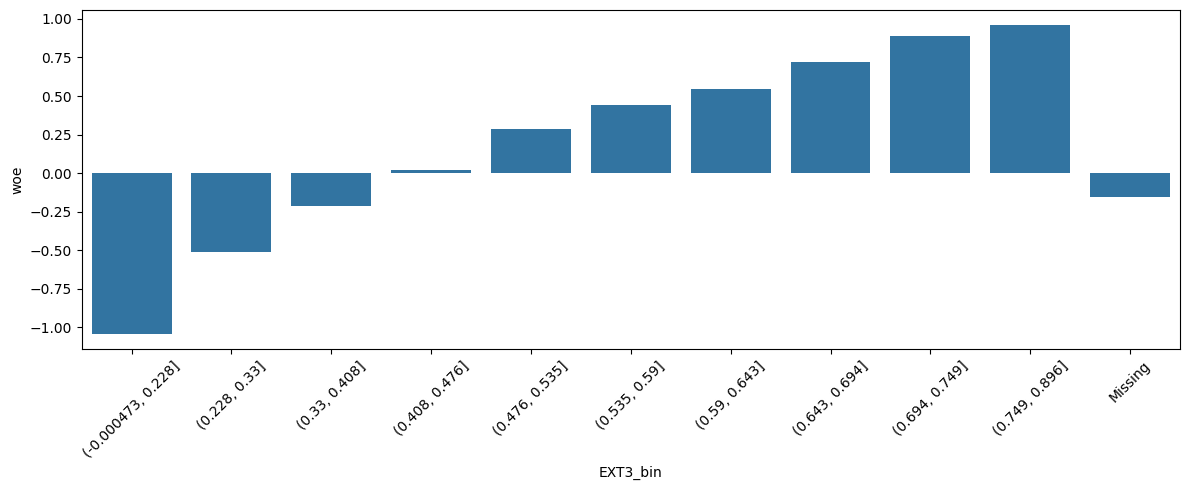

In [18]:
# Ex 4.1 — EXT_SOURCE_3 qcut into 10 + MISSING bin, WOE table

feat = 'EXT_SOURCE_3'

train['EXT3_bin'] = pd.qcut(train[feat], q=10, duplicates='drop', precision=3)
train['EXT3_bin'] = train['EXT3_bin'].cat.add_categories('Missing').fillna('Missing')

woe_table, iv = woe_iv_table(df=train, feature='EXT3_bin', target='TARGET', smoothing=0.5)
print(f'IV = {iv:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=woe_table, x='EXT3_bin', y='woe', ax=ax)
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()

EXT3_bin
NaN                    48805
(0.627, 0.717]         34384
(0.538, 0.627]         32858
(0.448, 0.538]         28923
(0.717, 0.806]         24413
(0.359, 0.448]         24361
(0.269, 0.359]         19344
(0.18, 0.269]          13932
(0.0901, 0.18]          9214
(0.806, 0.896]          6195
(-0.000368, 0.0901]     3579
Name: count, dtype: int64
IV = 0.4149


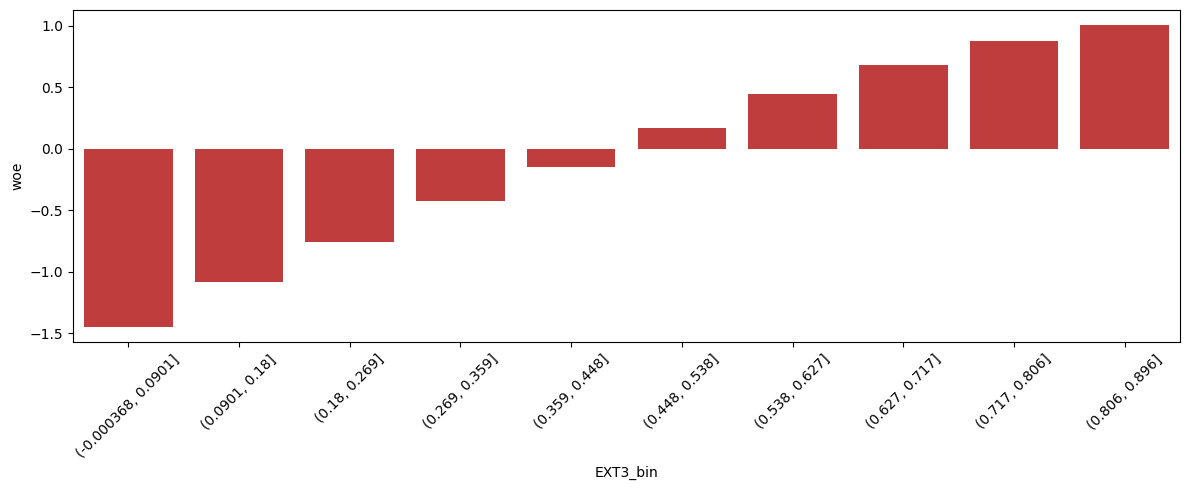

In [19]:
# Ex 4.2 — EXT_SOURCE_3 equal-width cut, compare counts + IV with qcut

train['EXT3_bin'] = pd.cut(train[feat], bins=10, duplicates='drop', precision=3)

print(train['EXT3_bin'].value_counts(dropna=False))

woe_table, iv = woe_iv_table(df=train, feature='EXT3_bin', target='TARGET', smoothing=0.5)
print(f'IV = {iv:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=woe_table, x='EXT3_bin', y='woe', ax=ax, color='tab:red')
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()

C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\3343839369.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['AGE_bins'] = pd.cut(train['AGE_YEARS'], bins=[20,25,30,35,40,45,50,55,60,100])


IV = 0.0870


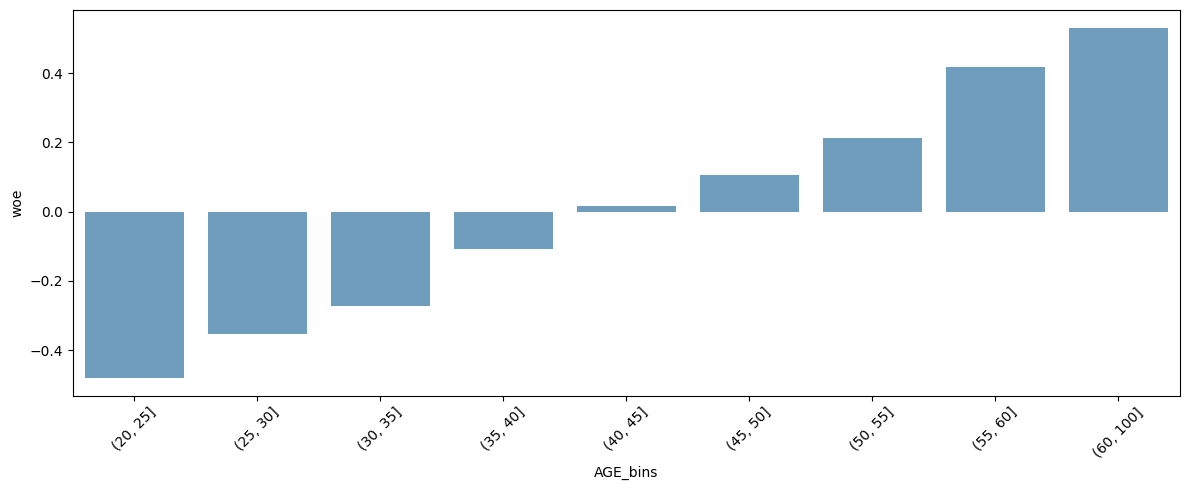

In [20]:
# Ex 4.3 — AGE_YEARS with business edges, WOE trend + monotonicity

train['AGE_bins'] = pd.cut(train['AGE_YEARS'], bins=[20,25,30,35,40,45,50,55,60,100])

woe_table, iv = woe_iv_table(df=train, feature='AGE_bins', target='TARGET', smoothing=0.5)
print(f'IV = {iv:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=woe_table, x='AGE_bins', y='woe', ax=ax, color='tab:blue', alpha=0.7)
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()


C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\1394459456.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['CREDIT_INCOME_RATIO_bins'] = pd.qcut(x=train['CREDIT_INCOME_RATIO'], q=8, precision=2)


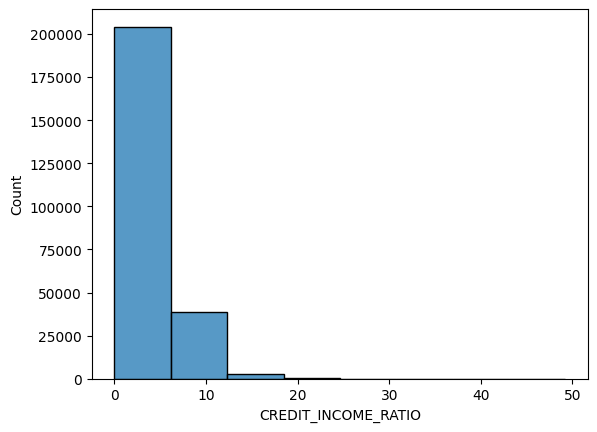

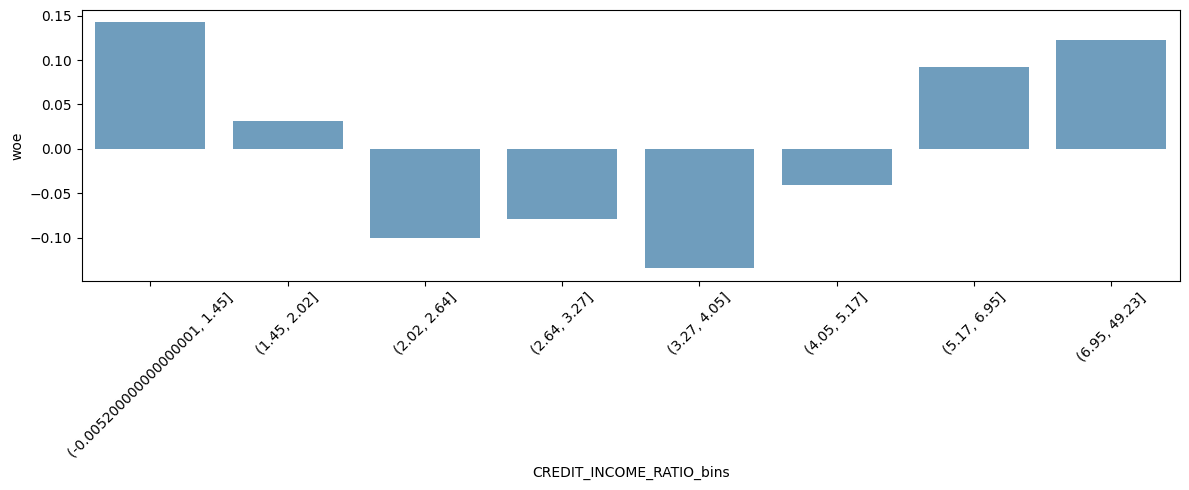

In [21]:
# Ex 4.4 — CREDIT_INCOME_RATIO qcut into 8, IV + trend

sns.histplot(data=train, x='CREDIT_INCOME_RATIO', bins=8, stat='count')

train['CREDIT_INCOME_RATIO_bins'] = pd.qcut(x=train['CREDIT_INCOME_RATIO'], q=8, precision=2)

woe_table, iv = woe_iv_table(train, 'CREDIT_INCOME_RATIO_bins', smoothing=0.5, target='TARGET')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=woe_table, x='CREDIT_INCOME_RATIO_bins', y='woe', ax=ax, color='tab:blue', alpha=0.7)
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()


**Your answers (4.1–4.4):**

**I 4.1** — Equal-frequency (`qcut`) gives more trustworthy WOEs on a right-skewed variable because every bin is guaranteed enough rows for a stable estimate. Equal-width (`cut`) puts almost all the mass in the low bins and starves the high tail — those tail bins hold only a handful of rows, so their good/bad split is high-variance: a few borrowers flipping swings the WOE wildly. A starved bin's WOE is noise, not signal. And because `IV = Σ (%good − %bad) · WOE`, a small-weight tail bin with a blown-up WOE *spuriously inflates IV* — making the feature look stronger than it is (the `smoothing=0.5` is what stops an empty bad-cell driving WOE to ±∞). Caveat: `qcut` still can't split a mass point — if one value repeats past a decile's width, adjacent quantile edges collide and `duplicates='drop'` silently returns fewer bins, so a large spike usually deserves its own dedicated bin.

**I 4.2** — Missingness in `EXT_SOURCE_3` is MNAR: the missing group is a distinct, higher-risk segment (thin-file / unproven borrowers the bureau doesn't cover), so "is it missing?" is genuine signal that deserves its own bin. Median-imputing *before* binning does double damage: (1) it averages the missing cohort's high bad-rate away, collapsing the widest-separation bin and **lowering IV**; and (2) it **poisons the central bin** the median lands in — that bin's WOE is pulled toward the risky end and is now wrong for *both* populations (overstates risk for genuine mid-score borrowers, understates it for the missing cohort), so every applicant scored into it gets a contaminated weight. A separate `MISSING` bin is strictly better on every axis. Median-impute is only defensible when missingness is genuinely random *and* rare — which this feature is not.

**🧠 4.3** — Reuse the **train** edges (b). Recomputing quantiles on `valid` is not target leakage (no labels are used) — it is an **inconsistency**: the bin→WOE map is a fixed function fitted on train and must be applied identically everywhere, or the same raw value maps to a different bin/WOE and `valid` stops testing the model you'll actually deploy. Decisive test: at scoring time you get **one applicant at a time** and physically cannot compute a quantile — anything you do to `valid` must be doable to one unseen row. Out-of-range values: `pd.cut` with fixed edges returns **`NaN`** for a value beyond the train min/max, which would break the WOE lookup or wrongly fall into `MISSING`. Fix: **open-ended terminal bins** — clamp the outer edges to `±inf` so out-of-range borrowers inherit the nearest bin's WOE. Never exclude (production must score everyone) and never route them to `MISSING` (an out-of-range *high* score is your safest borrower, not a missing one).


## 5 — Monotonic binning

For a scorecard (logistic regression on WOE), you usually *want* the WOE to move **monotonically** across an ordered feature's bins: as the score rises, risk should fall (or rise) without zig-zags. Monotonic WOE gives a scorecard that is interpretable ("more X always means safer") and resists over-fitting the wiggles of a particular sample.

The workflow: **fine-class** (many bins) → check the trend → **merge adjacent bins** until the WOE is monotonic (or the trend is smooth enough), subject to a minimum bin size.

**Key syntax**

```python
# quick monotonic-trend check: rank-correlation of bin order vs bin WOE
from scipy.stats import spearmanr
rho, _ = spearmanr(np.arange(len(tbl)), tbl["woe"].values)

# merge two adjacent bins by re-labelling, then recompute the table
# (many teams instead reach for a library — see Section 9 — but do it by hand once)
```

### Exercises

**5.1** — Take your 4.1 `EXT_SOURCE_3` decile table. Compute the Spearman correlation between bin index and WOE as a monotonicity score. If any decile breaks the trend, merge it with a neighbour and recompute until monotonic. Report bins before/after and the IV cost (if any) of enforcing monotonicity.

**5.2** — `AGE_YEARS` risk is often **U-shaped-ish** or monotone-ish but not perfectly. Fine-bin it (~10 bins), inspect the WOE trend, and decide: can you make it monotonic with sensible merges, or is a non-monotonic pattern real here? Defend your choice.

**5.3** — Write a small helper `is_monotonic(woe_series)` that returns whether a WOE vector is entirely non-increasing or non-decreasing, and use it to flag which of your Section 4 features are already monotonic.

**Interpretation 5.1** — Why does a logistic-regression scorecard prefer monotonic WOE? What interpretability and stability problems does a zig-zag WOE bin create for the people who *use* the scorecard?

**Interpretation 5.2** — Enforcing monotonicity almost always *lowers* IV a little. Why is accepting that small IV loss usually the right call? When would you refuse to force monotonicity?

**🧠 Conceptual 5.3** — Over-binning can produce a beautiful, perfectly monotonic WOE curve on `train` with a high IV — that then falls apart on `valid`. Explain how monotonicity and high in-sample IV can *coexist with* overfitting, and what out-of-sample check catches it (you'll build it in Section 8).

IV = 0.3296
rho =  0.745
Final rho =  1.0


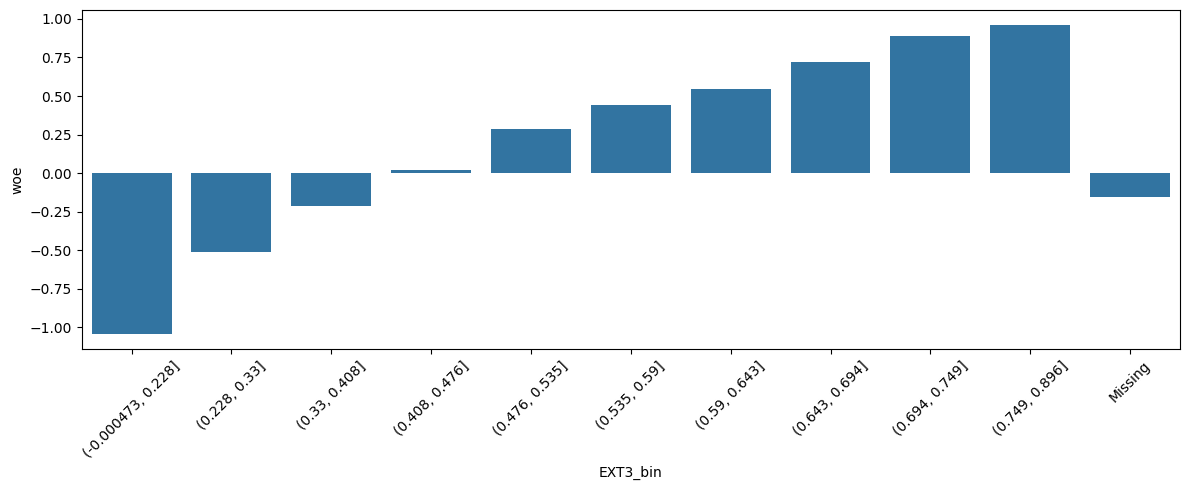

In [22]:
# Ex 5.1 — enforce monotonic WOE on EXT_SOURCE_3 by merging bins
from scipy.stats import spearmanr

feat = 'EXT_SOURCE_3'

train['EXT3_bin'] = pd.qcut(train[feat], q=10, duplicates='drop', precision=3)
train['EXT3_bin'] = train['EXT3_bin'].cat.add_categories('Missing').fillna('Missing')

woe_table, iv = woe_iv_table(df=train, feature='EXT3_bin', target='TARGET', smoothing=0.5)
print(f'IV = {iv:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=woe_table, x='EXT3_bin', y='woe', ax=ax)
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()

rho, _ = spearmanr(np.arange(len(woe_table)), woe_table['woe'].values)

print("rho = ", rho.round(3))

num = woe_table[woe_table.index != "Missing"]
rho, _ = spearmanr(np.arange(len(num)), num["woe"].values)   # ≈ 0.99+

missing_row = woe_table.loc[woe_table.index == "Missing"]

print("Final rho = ", rho.round(3))
# report its WOE and count alongside, not inside the trend check

# Final Rho after removing "Missing" bin is 1.0 - strong montonicity  

IV = 0.0870
Rho =  1.0


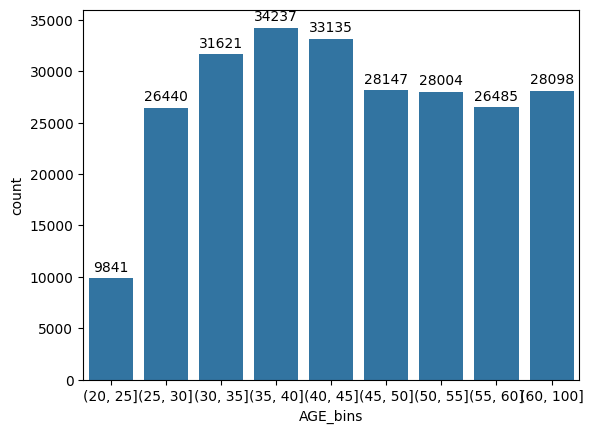

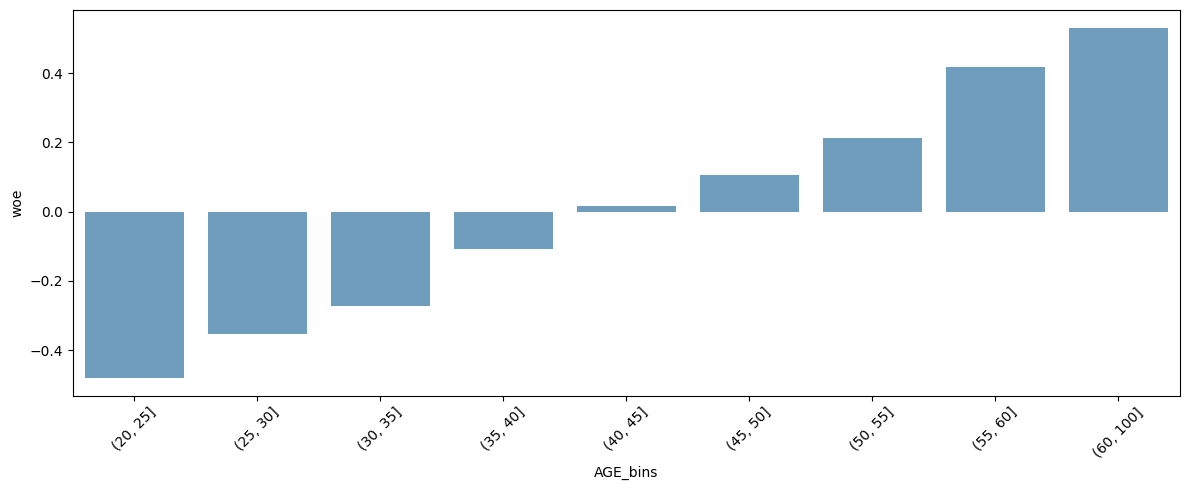

In [23]:
# Ex 5.2 — AGE_YEARS: is the non-monotonic pattern real? decide and defend

train['AGE_bins'] = pd.cut(train['AGE_YEARS'], bins=[20,25,30,35,40,45,50,55,60,100])

ax = sns.countplot(data = train, x='AGE_bins')
ax.bar_label(ax.containers[0], fmt='%d', padding=3)

woe_table, iv = woe_iv_table(df=train, feature='AGE_bins', target='TARGET', smoothing=0.5)
print(f'IV = {iv:.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=woe_table, x='AGE_bins', y='woe', ax=ax, color='tab:blue', alpha=0.7)
ax.tick_params(axis='x', rotation=45)

fig.tight_layout()

rho, _ = spearmanr(np.arange(len(woe_table)), woe_table['woe'].values)

print("Rho = ", rho)

# non monotonic pattern is not real with current binning strategy - fine leaving this binning strategy as is


In [24]:
# Ex 5.3 — is_monotonic(woe_series) helper + apply to Section 4 features

def is_monotonic(woe_series, drop=("Missing", "MISSING", "OTHER")):
    """True if the WOE vector is entirely non-increasing OR non-decreasing.

    woe_series : the 'woe' column from woe_iv_table, already in bin order.
    drop       : special bins to exclude from the trend (no place on the
                 risk continuum, e.g. the appended 'Missing' bin).
    """
    s = woe_series.drop(labels=[b for b in drop if b in woe_series.index])
    return bool(s.is_monotonic_increasing or s.is_monotonic_decreasing)


# --- rebuild the Section 4 binned columns so this cell runs standalone ---
train['EXT3_bin'] = pd.qcut(train['EXT_SOURCE_3'], q=10, duplicates='drop', precision=3)
train['EXT3_bin'] = train['EXT3_bin'].cat.add_categories('Missing').fillna('Missing')

train['AGE_bins'] = pd.cut(train['AGE_YEARS'], bins=[20,25,30,35,40,45,50,55,60,100])

train['CREDIT_INCOME_RATIO_bins'] = pd.qcut(train['CREDIT_INCOME_RATIO'], q=8, precision=2)

# --- flag which Section 4 features are already monotonic ---
section4 = {
    "EXT_SOURCE_3":        "EXT3_bin",
    "AGE_YEARS":           "AGE_bins",
    "CREDIT_INCOME_RATIO": "CREDIT_INCOME_RATIO_bins",
}

for name, col in section4.items():
    tbl, iv = woe_iv_table(train, col, smoothing=0.5)
    mono = is_monotonic(tbl["woe"])
    print(f"{name:22s} monotonic={mono!s:5s}  IV={iv:.4f}")

# quick sanity checks
assert is_monotonic(pd.Series([-0.8, -0.2, 0.1, 0.9])) is True     # rising
assert is_monotonic(pd.Series([0.9, 0.1, -0.2, -0.8])) is True     # falling
assert is_monotonic(pd.Series([-0.5, 0.2, -0.1, 0.4])) is False    # zig-zag
print("\nsanity checks passed")


EXT_SOURCE_3           monotonic=True   IV=0.3296
AGE_YEARS              monotonic=True   IV=0.0870
CREDIT_INCOME_RATIO    monotonic=False  IV=0.0101

sanity checks passed


**Your answers (5.1-5.3):**

**I 5.1** - Monotonic WOE isn't a mathematical requirement - the regression *can* represent a zig-zag fine, since each bin is just a WOE lookup scaled by one coefficient. We want monotonicity for two other reasons:
- **Interpretability / defensibility**: points per bin must move one way. A zig-zag can make a higher-income applicant score *lower* than a lower-income one - indefensible to the customer, to a fair-lending audit, and it breaks the adverse-action reason codes.
- **Stability**: a zig-zag is almost always sample noise. It won't reproduce next quarter, so those wiggles mis-score new applicants. Monotonicity acts as regularisation - it encodes the prior that risk moves smoothly with the feature.

**I 5.2** - The IV you lose by enforcing monotonicity is mostly the *noise-inflated* slice: the wiggles add fake separation that won't survive out of sample. So you're deleting fake predictive power, not real signal - the IV number drops but the model gets more trustworthy. **Refuse to force it** when the non-monotonic shape is genuinely real, judged by three tests together: (1) a plausible business/economic mechanism, (2) enough volume per bin that the WOE is precise not a fluke, and (3) the shape reproduces on a hold-out / different time period. AGE_YEARS is the classic - risk is U-shaped (young overextend, middle-aged most stable, older applicants taking new credit may be under stress). Forcing that monotonic would destroy real signal; instead segment or transform.

**5.3** - Monotonicity and high IV are **both computed on the training data**, so neither proves the model generalises - they're graded on the exam they've already seen. Over-binning manufactures both: tiny bins give noisy WOE estimates, IV rises mechanically as you add bins, and by splitting/merging until the train curve *happens* to look monotonic you're just selecting the one slicing that flatters this sample. It's the same overfitting as a zig-zag, wearing the opposite disguise - a suspiciously perfect staircase instead of obvious wiggles. The catch (Section 8): freeze the bin edges and WOE values learned on train, apply them **unchanged** to validation, and recompute IV and the trend there. Real structure survives (valid IV ~ train IV, shape holds); overfit structure collapses (valid IV craters, staircase falls apart). Do *not* re-bin or re-fit WOE on valid - that just lets it cheat again.


## 6 — WOE encoding: transforming features for the model

Once a feature is binned and its WOE table is settled **on train**, you *encode* it: replace each row's bin with that bin's WOE number. The model then sees a clean, monotone, log-odds-aligned numeric column.

The discipline that matters: **the mapping is fitted on `train` and merely applied to `valid`.** Unseen categories and out-of-range values in `valid` must map to something you decided in advance (commonly WOE = 0, i.e. "neutral / no evidence", or the WOE of a designated `OTHER`/`MISSING` bin).

**Key syntax**

```python
tbl, iv = woe_iv_table(train, "EXT3_bin")
woe_map = tbl["woe"].to_dict()               # {bin_label: woe}

def apply_woe(series_binned, woe_map, default=0.0):
    return series_binned.map(woe_map).fillna(default)

train["EXT3_woe"] = apply_woe(train["EXT3_bin"], woe_map)
valid["EXT3_bin"] = pd.cut(valid["EXT_SOURCE_3"], bins=train_edges)   # SAME edges
valid["EXT3_woe"] = apply_woe(valid["EXT3_bin"], woe_map, default=0.0)
```

### Exercises

**6.1** — Encode `EXT_SOURCE_3` (from your monotonic bins in Section 5) into `EXT3_woe` on **both** `train` and `valid`, reusing the train edges and the train WOE map. Confirm `valid` never influenced a WOE number.

**6.2** — Encode your coarse-classed `OCCUPATION_TYPE` and `NAME_EDUCATION_TYPE`. Handle a category present in `valid` but absent in `train` by routing it to your `default`. Show it works by checking for NaNs after mapping (there should be none).

**6.3** — Fit a `LogisticRegression` on a handful of WOE-encoded features (`EXT_SOURCE_3`, `EXT_SOURCE_2`, age, occupation, education) using `train`, and report train vs valid ROC AUC. Then print the fitted coefficients.

**Interpretation 6.1** — After WOE encoding, the logistic coefficient on a well-behaved feature should be **positive and not far from a shared value** across features. Why? (Recall Section 1: WOE is already on the log-odds scale.) What does a *negative* coefficient on a WOE feature warn you about?

**Interpretation 6.2** — Mapping unseen `valid` categories to WOE = 0 means "this bin gives no evidence either way". What is the risk of that default if the unseen category is actually high-risk, and how would monitoring catch it?

**🧠 Conceptual 6.3** — WOE encoding replaces a category with a single number derived from the target. That is a form of **target encoding**. Explain precisely why doing it on `train` only (and applying to `valid`) avoids the target-leakage that naive target encoding is infamous for — and what within-`train` trick (e.g. cross-fitting / out-of-fold) you'd add if `train` itself were small.

In [28]:
from scipy.stats import spearmanr

feat = 'EXT_SOURCE_3'

# 1. Learn bins on TRAIN
train['EXT3_bin'], train_edges = pd.qcut(
    train[feat], q=10, duplicates='drop', precision=3, retbins=True
)
train_edges[0], train_edges[-1] = -np.inf, np.inf

# 2. Apply SAME edges to VALID  -> now valid has EXT3_bin too
valid['EXT3_bin'] = pd.cut(valid[feat], bins=train_edges)

# 3. Only now can we touch EXT3_bin on both frames
for df in (train, valid):
    df['EXT3_bin'] = df['EXT3_bin'].cat.add_categories('Missing').fillna('Missing')

# 4. WOE learned on TRAIN
woe_table, iv = woe_iv_table(df=train, feature='EXT3_bin', target='TARGET', smoothing=0.5)
print(f'IV = {iv:.4f}')

num = woe_table[woe_table.index != 'Missing']
rho, _ = spearmanr(np.arange(len(num)), num['woe'].values)
print(f'monotonic rho = {rho:.4f}')

woe_map = woe_table['woe'].to_dict()

def apply_woe(series_binned, woe_map, default=0.0):
    return series_binned.map(woe_map).fillna(default)

train['EXT3_woe'] = apply_woe(train['EXT3_bin'], woe_map=woe_map, default=0.0)
valid['EXT3_woe'] = apply_woe(valid['EXT3_bin'], woe_map=woe_map, default=0.0)

IV = 0.3296
monotonic rho = 1.0000


C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\674412312.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  valid['EXT3_bin'] = pd.cut(valid[feat], bins=train_edges)
C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\674412312.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['EXT3_woe'] = apply_woe(train['EXT3_bin'], woe_map=woe_map, default=0.0)
C:\Users\evanr\AppData\Local\Temp\ipykernel_14052\674412312.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert

In [ ]:
train.sample(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,...,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,YEARS_EMPLOYED,YEARS_EMPLOYED_CLEAN,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,OCCUPATION_TYPE_c,NAME_INCOME_TYPE_c,EXT3_bin,AGE_bins,CREDIT_INCOME_RATIO_bins,EXT3_woe
30420,135306,0,Cash loans,F,Y,Y,0,112500.0,380533.5,19557.0,328500.0,"Spouse, partner",Working,Secondary / secondary special,Married,House / apartment,0.031329,-19750,-12221,-859.0,-2880,10.0,1,1,0,1,0,0,NaN,2.0,2,2,MONDAY,15,0,0,0,0,0,0,Industry: type 7,NaN,0.754228,0.540654,0.0825,0.0382,0.9876,0.83,NaN,0.08,0.0690,0.375,0.4167,0.0583,NaN,0.0849,NaN,0.0,0.0840,0.0396,0.9876,0.8367,NaN,0.0806,0.0690,...,NaN,0.0884,NaN,0.0,0.0833,0.0382,0.9876,0.8323,NaN,0.08,0.0690,0.375,0.4167,0.0593,NaN,0.0864,NaN,0.0,reg oper account,block of flats,0.0667,Panel,No,6.0,1.0,6.0,0.0,-587.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,7.0,54.072553,33.459274,33.459274,3.382520,0.173840,MISSING,Working,"(0.535, 0.59]","(50, 55]","(3.27, 4.05]",0.441999
220534,355480,0,Cash loans,F,N,Y,0,112500.0,91692.0,9063.0,81000.0,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,0.018634,-24337,365243,-7593.0,-4490,NaN,1,0,0,1,0,0,NaN,2.0,2,2,SUNDAY,10,0,0,0,0,0,0,XNA,NaN,0.744990,0.591977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,2.0,1.0,-1213.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,66.631075,-999.980835,NaN,0.815040,0.080560,MISSING,Pensioner,"(0.59, 0.643]","(60, 100]","(-0.005200000000000001, 1.45]",0.545394
42681,149410,0,Cash loans,M,Y,N,2,211500.0,290088.0,21109.5,229500.0,Unaccompanied,State servant,Secondary / secondary special,Married,House / apartment,0.009630,-12521,-2768,-2562.0,-4598,15.0,1,1,0,1,0,0,Drivers,4.0,2,2,TUESDAY,17,0,0,0,0,1,

In [ ]:
# Ex 6.2 — encode occupation + education; route unseen valid categories to default


woe_table_occupation, iv_occupation = woe_iv_table(df=train, feature='OCCUPATION_TYPE_c', target='TARGET', smoothing=0.5)
print(f'IV = {iv_occupation:.4f}')

woe_table_education, iv_education = woe_iv_table(df=train, feature='NAME_EDUCATION_TYPE', target='TARGET', smoothing=0.5)
print(f'IV = {iv_education:.4f}')

woe_map_occ = woe_table_occupation['woe'].to_dict()

woe_map_edu = woe_table_education['woe'].to_dict()

train['occ_woe'] = apply_woe(train['OCCUPATION_TYPE_c'], woe_map=woe_map_occ, default=0.0)
train['edu_woe'] = apply_woe(train['NAME_EDUCATION_TYPE'], woe_map=woe_map_edu, default=0.0)

valid['occ_woe'] = apply_woe(valid['OCCUPATION_TYPE'], woe_map=woe_map_occ, default=0.0)
valid['edu_woe'] = apply_woe(valid['NAME_EDUCATION_TYPE'], woe_map=woe_map_edu, default=0.0)


IV = 0.0428
IV = 0.0492


occ_woe
 0.000000    34328
-0.291931    10927
-0.189966     6496
 0.253048     5477
-0.065670     4275
Name: count, dtype: int64

In [ ]:
# Ex 6.3 — logistic regression on WOE features; train vs valid AUC + coefficients
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

features = ['EXT3_woe', 'occ_woe', 'edu_woe'] 

X_train, y_train = train[features], train['TARGET']
X_valid, y_valid = valid[features], valid['TARGET']

model = LogisticRegression()          # default L2, C=1.0 is fine here
model.fit(X_train, y_train)

# probability of default (class 1) — NOT predict()
train_pred = model.predict_proba(X_train)[:, 1]
valid_pred = model.predict_proba(X_valid)[:, 1]

print(f'Train AUC = {roc_auc_score(y_train, train_pred):.4f}')
print(f'Valid AUC = {roc_auc_score(y_valid, valid_pred):.4f}')

coefs = pd.Series(model.coef_[0], index=features).sort_values()
print(coefs)
print('intercept:', model.intercept_[0])


Train AUC = 0.6768
Valid AUC = 0.6504
EXT3_woe   -0.999515
edu_woe    -0.978305
occ_woe    -0.765897
dtype: float64
intercept: -2.4318630673762995


**Your answers (6.1–6.3):**

**I 6.1** —

**I 6.2** —

**🧠 6.3** —

## 7 — Visualising WOE & IV

A WOE table is easier to *trust* as a picture. Three plots earn their keep: WOE-by-bin (is it monotonic?), event-rate-by-bin overlaid (does WOE track risk as expected?), and an IV ranking bar chart for feature selection.

> Read the **dataviz** skill before styling these — one consistent look across all your WOE plots.

**Key syntax**

```python
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(tbl)), tbl["woe"], color="tab:blue", alpha=0.8)
ax.axhline(0, color="black", linewidth=1)            # WOE=0 = portfolio average
ax.set_xticks(range(len(tbl)), [str(i) for i in tbl.index], rotation=45, ha="right")

ax2 = ax.twinx()                                      # overlay bad rate
ax2.plot(range(len(tbl)), tbl["bad_rate"], color="tab:red", marker="o")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
```

### Exercises

**7.1** — WOE bar chart for `EXT_SOURCE_3` bins with a horizontal line at WOE = 0. Order bins by their natural interval order. Title it with the takeaway.

**7.2** — Same chart, but overlay the **bad rate** per bin on a twin axis. Confirm visually that (in goods-on-top convention) WOE and bad rate move in *opposite* directions. Explain in the title or a note why that is expected.

**7.3** — Compute IV for a candidate list of ~10 features (mix of your binned continuous and coarse-classed categoricals) and draw a **horizontal, sorted IV ranking bar chart**, with the Siddiqi band cutoffs (0.02, 0.1, 0.3, 0.5) drawn as reference lines.

**Interpretation 7.1** — What does a *zig-zag* WOE bar chart tell you to do before this feature goes near the model? What does a smooth monotonic one let you claim to a credit committee?

**🧠 Conceptual 7.2** — In your 7.2 twin-axis chart, WOE goes up while bad rate goes down. If someone hands you a WOE chart where WOE and bad rate move in the *same* direction, what has almost certainly happened — and is the feature wrong, or just the label?

IV = 0.3296
monotonic rho = 1.0000


Text(0.5, 1.0, 'Observable Montonic Relationship between EXT Source 3 and Default Rate Based on Woe Binning')

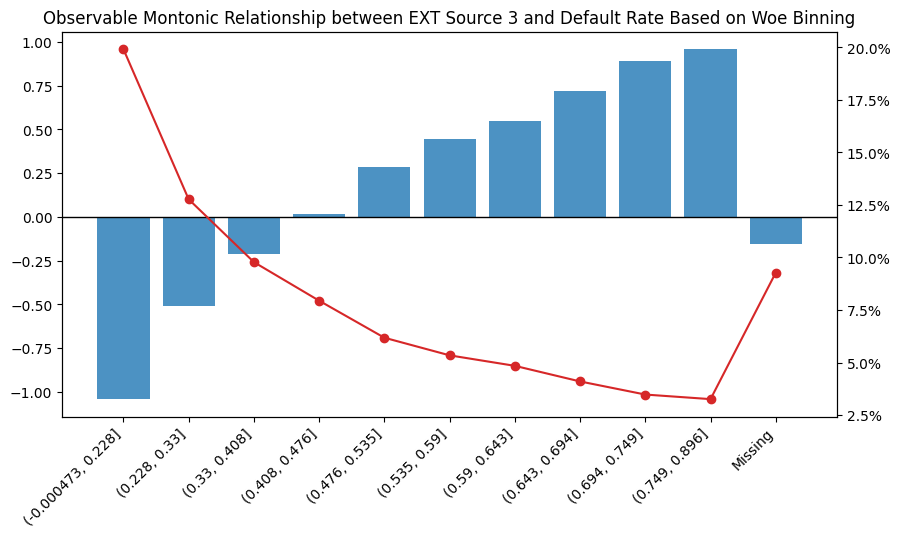

In [32]:
from scipy.stats import spearmanr

feat = 'EXT_SOURCE_3'

# 1. Learn bins on TRAIN
train['EXT3_bin'], train_edges = pd.qcut(
    train[feat], q=10, duplicates='drop', precision=3, retbins=True
)
train_edges[0], train_edges[-1] = -np.inf, np.inf

# 2. Apply SAME edges to VALID  -> now valid has EXT3_bin too
valid['EXT3_bin'] = pd.cut(valid[feat], bins=train_edges)

# 3. Only now can we touch EXT3_bin on both frames
for df in (train, valid):
    df['EXT3_bin'] = df['EXT3_bin'].cat.add_categories('Missing').fillna('Missing')

# 4. WOE learned on TRAIN
woe_table, iv = woe_iv_table(df=train, feature='EXT3_bin', target='TARGET', smoothing=0.5)
print(f'IV = {iv:.4f}')

num = woe_table[woe_table.index != 'Missing']
rho, _ = spearmanr(np.arange(len(num)), num['woe'].values)
print(f'monotonic rho = {rho:.4f}')

woe_map = woe_table['woe'].to_dict()

def apply_woe(series_binned, woe_map, default=0.0):
    return series_binned.map(woe_map).fillna(default)

train['EXT3_woe'] = apply_woe(train['EXT3_bin'], woe_map=woe_map, default=0.0)
valid['EXT3_woe'] = apply_woe(valid['EXT3_bin'], woe_map=woe_map, default=0.0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(woe_table)), woe_table["woe"], color="tab:blue", alpha=0.8)
ax.axhline(0, color="black", linewidth=1)            # WOE=0 = portfolio average
ax.set_xticks(range(len(woe_table)), [str(i) for i in woe_table.index], rotation=45, ha="right")

ax2 = ax.twinx()                                      # overlay bad rate
ax2.plot(range(len(woe_table)), woe_table["bad_rate"], color="tab:red", marker="o")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

ax.set_title("Observable Montonic Relationship between EXT Source 3 and Default Rate Based on Woe Binning")


In [ ]:
# Ex 7.2 — WOE bars + bad-rate line on twin axis

# SEE ABOVE

In [ ]:
# Ex 7.3 — sorted IV ranking bar chart with Siddiqi band cutoffs

siddiqi_bands = 

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(woe_table)), woe_table["woe"], color="tab:blue", alpha=0.8)
ax.axhline(0, color="black", linewidth=1)            # WOE=0 = portfolio average
ax.set_xticks(range(len(woe_table)), [str(i) for i in woe_table.index], rotation=45, ha="right")

ax2 = ax.twinx()                                      # overlay bad rate
ax2.plot(range(len(woe_table)), woe_table["bad_rate"], color="tab:red", marker="o")
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

**Your answers (7.1, 7.2):**

**I 7.1** —

**🧠 7.2** —

## 8 — Pitfalls: leakage, stability (PSI), and over-binning

The formulas are easy; the judgement is the job. Three failure modes to build defences against.

**Stability — Population Stability Index.** PSI uses the *same math shape* as IV, but compares **the same feature across two populations** (train vs valid, or last-quarter vs this-quarter) instead of goods vs bads:

$$
\text{PSI} \;=\; \sum_i \left( \%\text{Actual}_i - \%\text{Expected}_i \right)\,\ln\!\left(\frac{\%\text{Actual}_i}{\%\text{Expected}_i}\right)
$$

Bands: **< 0.1** stable, **0.1–0.25** some shift (watch), **> 0.25** significant shift (act).

**Key syntax**

```python
def psi(expected_binned, actual_binned):
    e = expected_binned.value_counts(normalize=True)
    a = actual_binned.value_counts(normalize=True).reindex(e.index).fillna(1e-6)
    return float(((a - e) * np.log(a / e)).sum())
```

### Exercises

**8.1** — Compute PSI for `EXT_SOURCE_3` bins between `train` (expected) and `valid` (actual), reusing your train edges. Interpret against the bands. (A clean random split should be very stable — near 0.)

**8.2** — Over-binning demo: qcut `EXT_SOURCE_2` into **50** bins on `train`, compute IV on `train`, then apply the *same* bins+WOE map to `valid` and recompute a validation IV. Compare. Then do the same with **8** bins. What does the 50-bin gap tell you?

**8.3** — Leakage hunt: scan a handful of features for a **suspiciously high IV** (> 0.5). Pick one flagged feature (if any) and reason about whether it is genuine signal or leakage. If none in your list exceed 0.5, say what a leaky feature would look like here (e.g. a field only populated post-decision).

**Interpretation 8.1** — IV and PSI are the same arithmetic. State crisply what each *holds fixed* and what each *compares*, and why a feature can have high IV **and** high PSI (predictive but unstable) — and why you might still reject it.

**Interpretation 8.2** — From 8.2: why does train IV rise as you add bins while valid IV eventually falls? Name the bias–variance story in WOE terms.

**🧠 Conceptual 8.3** — "Reject inference": your training data only contains *accepted* applicants (the rejected ones never got a loan, so have no `TARGET`). How does this bias the WOE/IV you estimate, and in which direction would it distort the WOE of a risk-segregating feature? (Conceptual — no code required.)

In [ ]:
# Ex 8.1 — PSI of EXT_SOURCE_3 bins, train (expected) vs valid (actual)
def psi(expected_binned, actual_binned):
    ...

In [ ]:
# Ex 8.2 — over-binning: 50 bins vs 8 bins, train IV vs valid IV

In [ ]:
# Ex 8.3 — scan for IV > 0.5; reason about leakage vs genuine signal

**Your answers (8.1–8.3):**

**I 8.1** —

**I 8.2** —

**🧠 8.3** —

## 9 — Doing it with a library (`optbinning`)

You have now done WOE/IV by hand — which is the only way to actually understand it. In production, teams use a solver that chooses bin edges to **maximise IV subject to constraints** (minimum bin size, monotonic trend, max bins). `optbinning` is the common choice (`scorecardpy` is another).

```python
# pip install optbinning   (run once in your env if missing)
from optbinning import OptimalBinning

optb = OptimalBinning(name="EXT_SOURCE_3", dtype="numerical",
                      monotonic_trend="auto", min_bin_size=0.05)
optb.fit(train["EXT_SOURCE_3"].values, train["TARGET"].values)

optb.binning_table.build()          # WOE/IV table
train_woe = optb.transform(train["EXT_SOURCE_3"].values, metric="woe")
valid_woe = optb.transform(valid["EXT_SOURCE_3"].values, metric="woe")   # train-learned bins
```

> If `optbinning` will not install in your environment, skip the code but still answer the interpretation questions — and note what you would have compared.

### Exercises

**9.1** — `OptimalBinning` on `EXT_SOURCE_3` with `min_bin_size=0.05` and a monotonic trend. Compare its bins, WOE values, and IV against your **hand-built monotonic** version from Section 5. Where do they agree/differ?

**9.2** — Use `BinningProcess` to bin a *list* of ~8 features at once, pull out the IV of each, and rank them. Compare the ranking to your hand-computed 7.3 ranking.

**9.3** — Re-fit 9.1 with `monotonic_trend=None` and a larger `max_n_bins`. Does IV go up? Does the extra IV survive on `valid`? Tie this back to Section 8.

**Interpretation 9.1** — The solver "maximises IV subject to constraints". Why are the *constraints* (min bin size, monotonic trend, max bins) the important part — what would unconstrained IV-maximisation produce?

**🧠 Conceptual 9.2** — A colleague reports IV = 0.61 for a feature straight from `optbinning` with default settings and wants to include it. Walk through the three checks you would run before believing it is a great feature rather than a red flag.

In [ ]:
# Ex 9.1 — OptimalBinning on EXT_SOURCE_3 vs your hand-built monotonic bins
# from optbinning import OptimalBinning

In [ ]:
# Ex 9.2 — BinningProcess over ~8 features; IV ranking vs your 7.3 ranking
# from optbinning import BinningProcess

In [ ]:
# Ex 9.3 — unconstrained (monotonic_trend=None, more bins): train IV vs valid IV

**Your answers (9.1, 9.2):**

**I 9.1** —

**🧠 9.2** —

## 10 — Capstone: a WOE/IV feature-selection table for the PD model

Everything above, combined into the artefact you actually hand off: a ranked, cleaned, WOE-encoded feature set ready for a scorecard. No new syntax — this is composition, discipline, and judgement.

**The brief**

Working **on `train` only** for all learning, and applying to `valid`:

1. **Candidate set** — assemble ~12 features (a mix): `EXT_SOURCE_1/2/3`, `AGE_YEARS`, `YEARS_EMPLOYED_CLEAN`, `CREDIT_INCOME_RATIO`, `ANNUITY_INCOME_RATIO`, `NAME_EDUCATION_TYPE`, `OCCUPATION_TYPE`, `NAME_INCOME_TYPE`, `NAME_FAMILY_STATUS`, `REGION_RATING_CLIENT`.
2. **Bin each** — qcut/monotonic for continuous, coarse-class for categorical, `MISSING` bins throughout.
3. **Build a summary table** — one row per feature: `n_bins`, `IV`, IV band (Siddiqi), monotonic? (Y/N), PSI(train→valid). Sort by IV descending.
4. **Select** — apply a written rule (e.g. keep 0.02 ≤ IV ≤ 0.5, PSI < 0.25, drop one of any pair that is redundant — check with a quick correlation of the WOE-encoded columns).
5. **Encode** the selected features to WOE on `train` and `valid`, and fit a `LogisticRegression`; report train/valid AUC.
6. **One figure** — a sorted IV ranking bar chart of the candidates with the band cutoffs marked (reuse 7.3), saved to PNG at 150 dpi.

**Then write the analysis** (markdown cell below): a **decision statement per selected/rejected feature** in *observation → decision* form.

> Example: "EXT_SOURCE_3: IV 0.34 (strong), monotonic, PSI 0.01 → keep, WOE-encoded, expect a large scorecard weight. EXT_SOURCE_1: IV 0.15 but 56% missing and PSI 0.08 → keep with an explicit MISSING bin, flag the missingness to the committee."

**Requirements:** all WOE/IV/PSI learned on `train`; every feature has a `MISSING` bin where relevant; the summary table and the figure are both produced; the selection rule is written down *before* you read the table.

In [ ]:
# Capstone — build the WOE/IV feature-selection table here.
# (Develop each feature's binning in its own scratch cell first, then assemble the summary.)

**Capstone decision statements:**

Selection rule (written before reading the table):

Feature-by-feature (observation → decision):

- EXT_SOURCE_3:
- EXT_SOURCE_2:
- EXT_SOURCE_1:
- AGE_YEARS:
- YEARS_EMPLOYED_CLEAN:
- CREDIT_INCOME_RATIO:
- ANNUITY_INCOME_RATIO:
- NAME_EDUCATION_TYPE:
- OCCUPATION_TYPE:
- NAME_INCOME_TYPE:
- NAME_FAMILY_STATUS:
- REGION_RATING_CLIENT:

Model result (train vs valid AUC) and what it says about the selected set:

## 11 — Self-test: can you answer these cold?

Close the notebook docs. If any of these are shaky, redo the relevant section.

1. Write the WOE formula and state your sign convention. In it, does a **high WOE** mean safer or riskier?
2. Why are the distributions computed *within class* (goods out of all goods, bads out of all bads) rather than as a share of all rows? What does that buy you under class imbalance?
3. Write the IV formula. Why is every bin's contribution non-negative, and why is that both convenient and a limitation?
4. State the Siddiqi IV bands. Why is IV > 0.5 a warning rather than a prize?
5. WOE = (bin log-odds) − (portfolio log-odds). Why does that identity make WOE-encoded features ideal for logistic regression?
6. Equal-frequency vs equal-width binning — when do you reach for each, and what is the "starved bin" failure?
7. Why give missing values their own WOE bin instead of imputing before binning?
8. Why do scorecards prefer monotonic WOE, and what do you sacrifice to enforce it?
9. Everything WOE/IV must be learned on `train` only. Describe the exact leak that happens if you compute WOE on all data before splitting.
10. IV and PSI are the same arithmetic — what does each hold fixed and compare, and what are the PSI action bands?
11. WOE encoding is target encoding. Why does the train-only discipline defuse the usual target-leakage objection?
12. Give one case where a *non-monotonic* WOE pattern is genuinely real and you should keep it.

**When you're done:** bring your completed sections to Claude for marking — the WOE/IV tables, the plots, and the written answers. This feeds straight into building the logistic scorecard for the PD model.

### Appendix — a compact reference implementation

Once you have built these by hand, this is a tidy version worth keeping. Fill in / verify it against your own Section 2 function rather than copying blindly.

In [ ]:
# Reference WOE/IV utility (goods-on-top convention). Verify against your own before trusting it.
def woe_iv(data, feature, target="TARGET", smoothing=0.5):
    g = data.groupby(feature, dropna=False)[target]
    t = pd.DataFrame({"good": g.apply(lambda s: (s == 0).sum()),
                      "bad":  g.apply(lambda s: (s == 1).sum())})
    G = t["good"].sum() + smoothing * len(t)
    B = t["bad"].sum()  + smoothing * len(t)
    t["dist_good"] = (t["good"] + smoothing) / G
    t["dist_bad"]  = (t["bad"]  + smoothing) / B
    t["woe"]       = np.log(t["dist_good"] / t["dist_bad"])
    t["bad_rate"]  = t["bad"] / (t["good"] + t["bad"])
    t["iv"]        = (t["dist_good"] - t["dist_bad"]) * t["woe"]
    return t, t["iv"].sum()

# tbl, iv = woe_iv(train, "NAME_EDUCATION_TYPE")
# display(tbl.sort_values("woe")); print("IV:", round(iv, 4))